In [108]:
import xarray as xr
from datetime import datetime, timezone, timedelta
import numpy as np
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from src.model_utils import get_tide_time, get_tide_series, get_tide_map
from src import store_adapter
from src.store_adapter import get_zarr_path
from src.query_planner import plan_bbox

In [109]:
import matplotlib.pyplot as plt

def plot_tide_level(tide, dtime, miny=None, maxy=None, intervaly=None):
    miny = min(tide) if miny is None else miny
    maxy = max(tide) if maxy is None else maxy
    intervaly = (maxy-miny)/8 if intervaly is None else intervaly
    miny = int(miny)
    maxy = int(maxy)
    intervaly = int(intervaly)

    plt.figure(figsize=(18, 4))
    plt.plot(dtime, tide, marker='o')
    plt.xlabel('Time')
    plt.ylabel('Tidal height')
    plt.yticks(list(range(miny, maxy+1, intervaly)),
               [str(i) for i in range(miny, maxy+1, intervaly)])
    plt.grid()
    plt.show()

In [110]:
#dz = xr.open_zarr('../data/tpxo10.zarr', consolidated=True, decode_times=False, mask_and_scale=False)
adapter = store_adapter.open_store('../data/tpxo10.zarr')
dz = adapter.ds
print(dz)

<xarray.Dataset> Size: 36GB
Dimensions:       (lat_u: 5401, lon_u: 10800, lat_v: 5401, lon_v: 10800,
                   lat_z: 5401, lon_z: 10800, constituents: 15)
Coordinates:
  * lat_u         (lat_u) float64 43kB -90.0 -89.97 -89.93 ... 89.93 89.97 90.0
  * lon_u         (lon_u) float64 86kB 0.01667 0.05 0.08333 ... 359.9 360.0
  * lat_v         (lat_v) float64 43kB -90.02 -89.98 -89.95 ... 89.95 89.98
  * lon_v         (lon_v) float64 86kB 0.03333 0.06667 0.1 ... 359.9 360.0 360.0
  * lat_z         (lat_z) float64 43kB -90.0 -89.97 -89.93 ... 89.93 89.97 90.0
  * lon_z         (lon_z) float64 86kB 0.03333 0.06667 0.1 ... 359.9 360.0 360.0
  * constituents  (constituents) <U3 180B '2n2' 'k1' 'k2' ... 'q1' 's1' 's2'
Data variables: (12/18)
    hu            (lat_u, lon_u) float32 233MB ...
    hv            (lat_v, lon_v) float32 233MB ...
    hz            (lat_z, lon_z) float32 233MB ...
    u_Im          (lat_u, lon_u, constituents) int32 3GB ...
    u_Re          (lat_u, lon_u, 

In [111]:
start_date = datetime(2024, 4, 2) #datetime(2023, 7, 25)
end_date = datetime(2024, 4, 5) #datetime(2023, 7, 28)


tide_time, dtime = get_tide_time(start_date, end_date)
ilon = 121.623611 #122.26672 #335
ilat = 23.980556 #23.76175 #30
#grid_sz = 1/30

dsub = adapter.sel_bbox(ilon, ilon+5, ilat, ilat+5)
print(dsub)

<xarray.Dataset> Size: 15GB
Dimensions:       (lat_u: 5401, lon_u: 10800, lat_v: 5401, lon_v: 10800,
                   lat_z: 150, lon_z: 150, constituents: 15)
Coordinates:
  * lat_u         (lat_u) float64 43kB -90.0 -89.97 -89.93 ... 89.93 89.97 90.0
  * lon_u         (lon_u) float64 86kB 0.01667 0.05 0.08333 ... 359.9 360.0
  * lat_v         (lat_v) float64 43kB -90.02 -89.98 -89.95 ... 89.95 89.98
  * lon_v         (lon_v) float64 86kB 0.03333 0.06667 0.1 ... 359.9 360.0 360.0
  * lat_z         (lat_z) float64 1kB 24.0 24.03 24.07 24.1 ... 28.9 28.93 28.97
  * lon_z         (lon_z) float64 1kB 121.6 121.7 121.7 ... 126.5 126.6 126.6
  * constituents  (constituents) <U3 180B '2n2' 'k1' 'k2' ... 'q1' 's1' 's2'
Data variables: (12/18)
    hu            (lat_u, lon_u) float32 233MB ...
    hv            (lat_v, lon_v) float32 233MB ...
    hz            (lat_z, lon_z) float32 90kB ...
    u_Im          (lat_u, lon_u, constituents) int32 3GB ...
    u_Re          (lat_u, lon_u, consti

In [112]:
sub = adapter.sel_point(ilon, ilat, tol=0.5/30.0)
amp, ph = adapter.amp_ph(sub, 'z')                # masked array,shape (ncons,)
cons = np.asarray(adapter.constituents)

tide_level = get_tide_series(
    np.ma.filled(amp, np.nan),     # flag==2 invalid -> NaN(不是 0)
    np.ma.filled(ph,  np.nan),
    cons, tide_time,
    format='netcdf', unit='cm', drop_mask=True)   # drop_mask=True -> 回傳 ndarray(invalid 為 NaN)

print(tide_level, np.nanmax(tide_level), np.nanmin(tide_level))

[ 28.82861473  37.26138862  41.86111113  41.0868493   34.26340826
  21.79054642   5.21220481 -12.97640979 -29.83104932 -42.64859482
 -49.59448629 -50.03831163 -44.52981212 -34.52339885 -22.02107196
  -9.23072581   1.77278727   9.42310747  13.02963266  12.98680718
  10.67060587   7.99884815   6.81228037   8.32507748  12.82961882
  19.68175866  27.47039879  34.27247649  37.97670459  36.71349167
  29.37534051  16.08606777  -1.60114873 -20.93149667 -38.56816229
 -51.38512493 -57.16015941 -54.99275382 -45.42464087 -30.32605495
 -12.58948087   4.38266748  17.39306366  24.24571123  24.3697044
  19.00064666  10.80323316   3.06046653  -1.27005686  -0.32824822
   6.21492457  17.07689171  29.58961833  40.21152087  45.31642339
  42.16588162  29.81743547   9.62824181 -14.90182871 -38.95084124
 -57.58639887 -66.96508839 -65.19091552 -52.69233734 -32.12987594
  -7.88731232  14.81513964  31.10355777  37.70342268  33.88727011
  21.73805827   5.56511841  -9.35115334] 45.31642339301774 -66.96508838837578

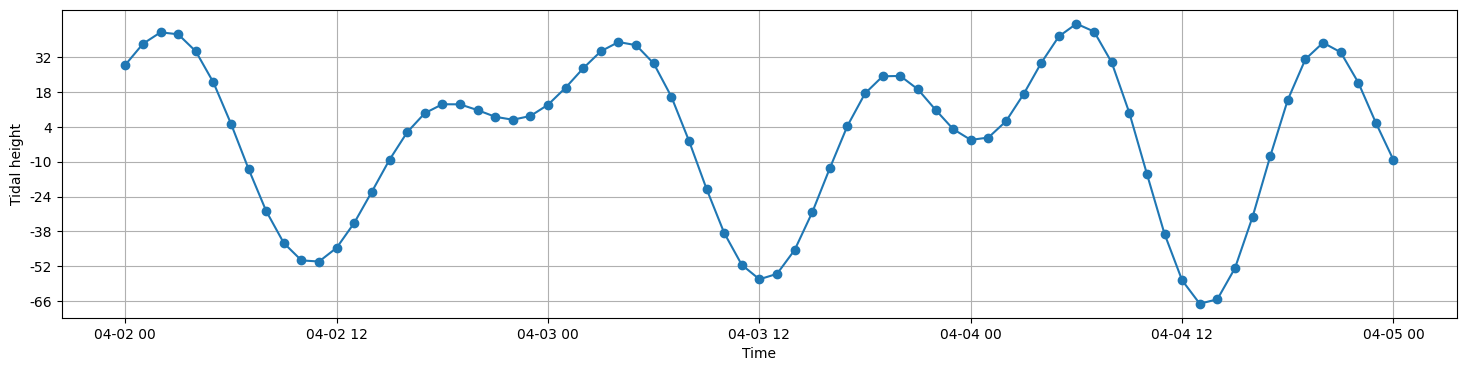

In [113]:
plot_tide_level(tide_level, dtime)

In [114]:
def current_quiver(adapter, x0, y0, x1, y1, tide_time, mask_grid=5, normalize=True):
    # bbox + 每 mask_grid 點抽樣 == 舊版的 (X % n == 0) & (Y % n == 0)
    sub, _ = plan_bbox(adapter, x0, x1, y0, y1, sample=mask_grid,
                       halo=0.5/30.0, max_cells=10_000_000)   # 繪圖用途,放寬 cap
    tide = get_tide_map(adapter, sub, tide_time[0:1],
                        type=['u', 'v'], drop_dim=False)       # (ny, nx, 1)
    glon, glat = adapter.coord_values(sub)
    LON, LAT = np.meshgrid(glon, glat)
    u0 = np.ma.filled(tide['u'][:, :, 0], np.nan)     # cm/s,invalid 格為 NaN
    v0 = np.ma.filled(tide['v'][:, :, 0], np.nan)
    mag = np.sqrt(u0**2 + v0**2)
    u, v = (u0/mag, v0/mag) if normalize else (u0, v0)
    return LON.ravel(), LAT.ravel(), u.ravel(), v.ravel(), mag.ravel()

In [115]:
def plot_current_gradients(x, y, u, v, mag, label_time, magmax=50):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Use boolean indexing to filter the data points whose magnitude is below magmax
    valid_indices = mag < magmax
    x = x[valid_indices]
    y = y[valid_indices]
    u = u[valid_indices]
    v = v[valid_indices]
    clipped_mag = mag[valid_indices]
    
    # Plotting, note the "angles" and "scale" parameters
    quiver = ax.quiver(x, y, u, v, clipped_mag, angles='xy', scale_units='xy',
                       scale=3, pivot='middle', width=0.003, cmap='jet')
    plt.colorbar(quiver, ax=ax, label='Current speed')
    
    ax.set_title('Tidal Currents at ' + str(label_time))
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')

    plt.show()

In [116]:
start_date = datetime(2023, 7, 25) #datetime(2024, 8, 4, 5, 30) #
end_date = datetime(2023, 7, 28) #datetime(2024, 8, 4, 7, 0) #
tide_time, dtime = get_tide_time(start_date, end_date)

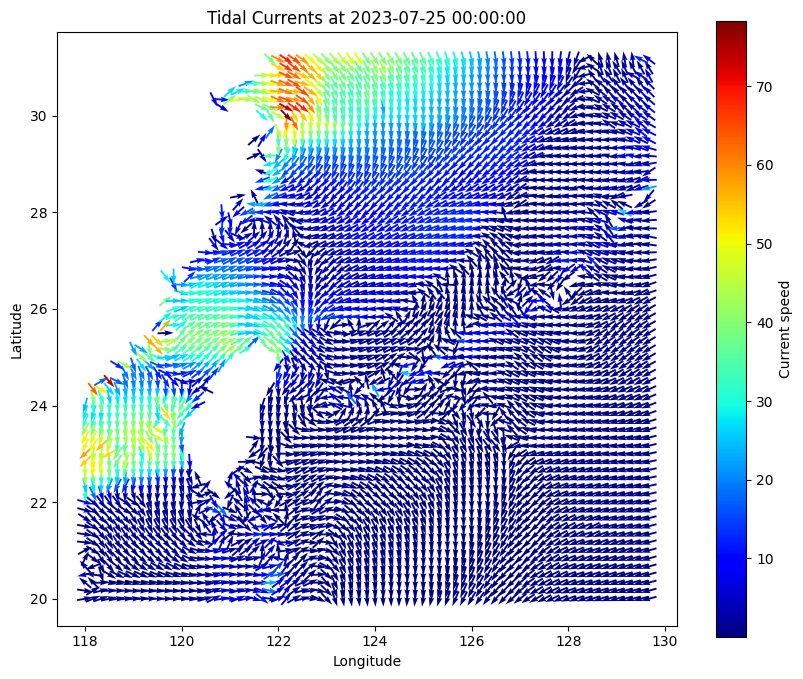

In [117]:
x01, y01, u01, v01, mag01 = current_quiver(adapter, 118.0, 20.0, 129.75, 31.25, tide_time, mask_grid=5)
plot_current_gradients(x01, y01, u01, v01, mag01, dtime[0], magmax=500)

In [118]:
start_date = datetime(2024, 8, 4, 5, 30) #
end_date = datetime(2024, 8, 4, 7, 0) #
tide_time, dtime = get_tide_time(start_date, end_date)
print(dtime[0])
x1, y1, u1, v1, mag1 = current_quiver(adapter, 280, 0, 360, 60, tide_time, mask_grid=5)

2024-08-04 05:30:00


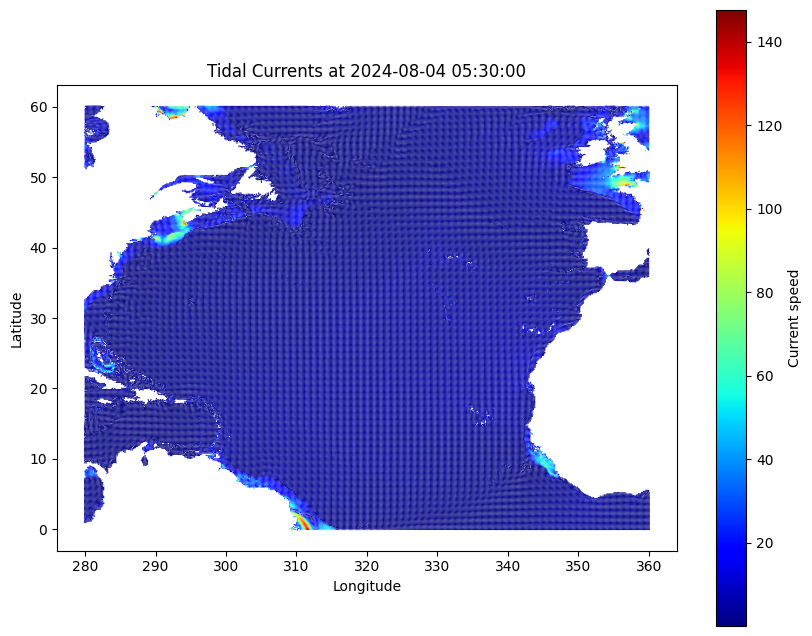

In [119]:
plot_current_gradients(x1, y1, u1, v1, mag1, dtime[0], magmax=150)

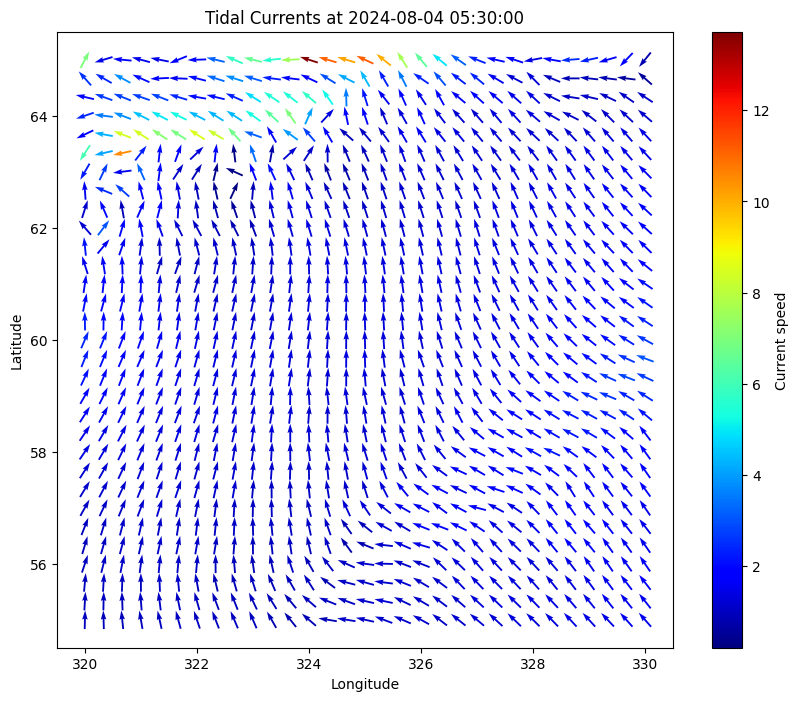

In [120]:
x1s, y1s, u1s, v1s, mag1s = current_quiver(adapter, 320, 55, 330, 65, tide_time, mask_grid=10)
plot_current_gradients(x1s, y1s, u1s, v1s, mag1s, dtime[0], magmax=500)

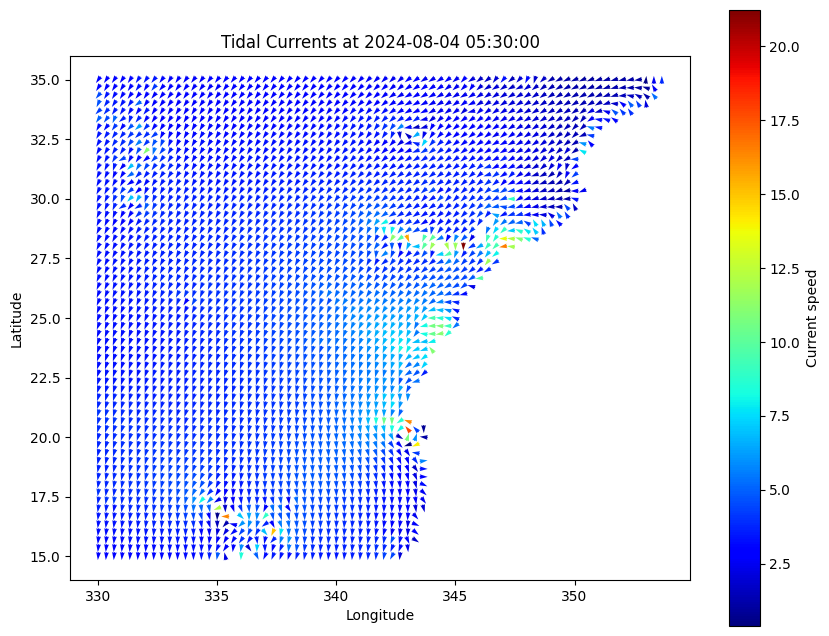

In [121]:
x1t, y1t, u1t, v1t, mag1t = current_quiver(adapter, 330, 15, 359.9, 35, tide_time, mask_grid=10)
plot_current_gradients(x1t, y1t, u1t, v1t, mag1t, dtime[0], magmax=500)

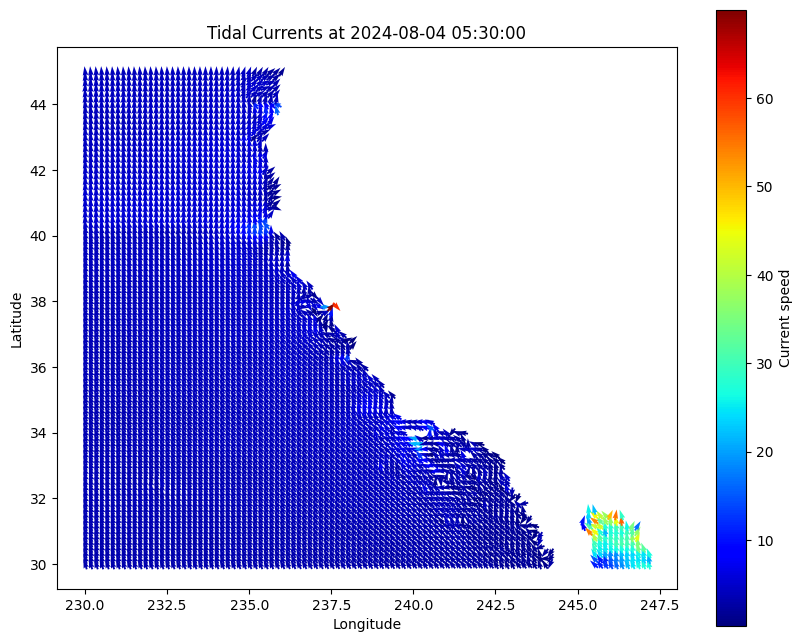

In [122]:
x3, y3, u3, v3, mag3 = current_quiver(adapter, 230, 30, 250, 45, tide_time, mask_grid=5)
plot_current_gradients(x3, y3, u3, v3, mag3, dtime[0], magmax=150)

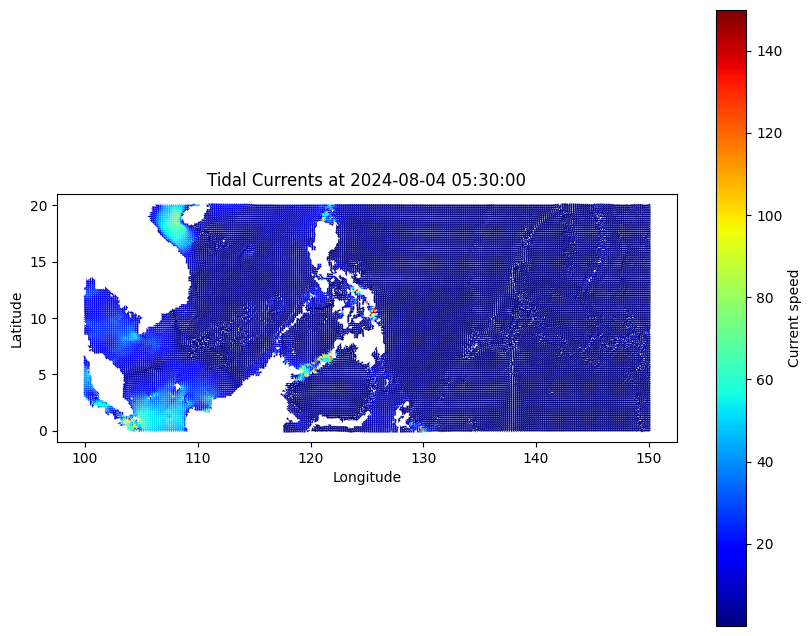

In [123]:
x3u, y3u, u3u, v3u, mag3u = current_quiver(adapter, 100, 0, 150, 20, tide_time, mask_grid=5)
plot_current_gradients(x3u, y3u, u3u, v3u, mag3u, dtime[0], magmax=150)

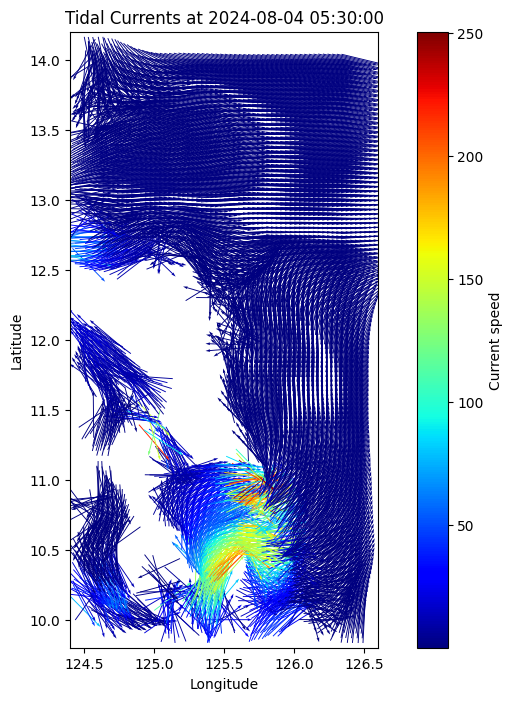

In [124]:
x3i, y3i, u3i, v3i, mag3i = current_quiver(adapter, 124.5, 10, 126.5, 14, tide_time, mask_grid=1)
plot_current_gradients(x3i, y3i, u3i, v3i, mag3i, dtime[0], magmax=500)

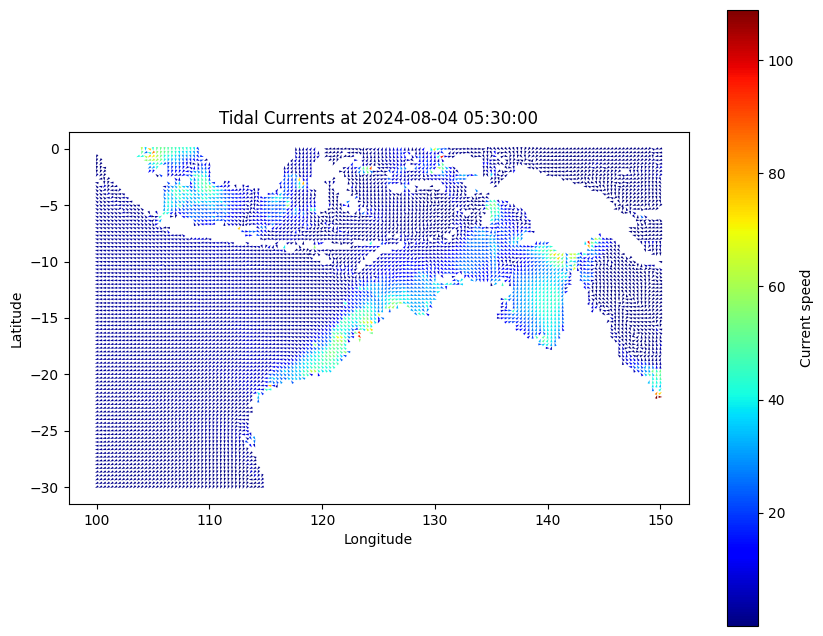

In [125]:
#Indian Ocean
x2, y2, u2, v2, mag2 = current_quiver(adapter, 100, -30, 150, 0, tide_time, mask_grid=10)
plot_current_gradients(x2, y2, u2, v2, mag2, dtime[0], magmax=150)

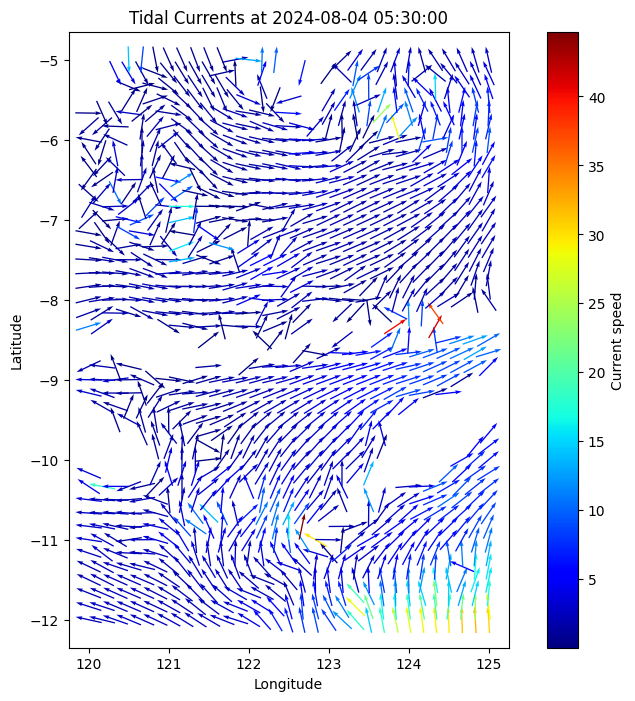

In [126]:
x2t, y2t, u2t, v2t, mag2t = current_quiver(adapter, 120, -12, 125, -5, tide_time, mask_grid=5)
plot_current_gradients(x2t, y2t, u2t, v2t, mag2t, dtime[0], magmax=150)

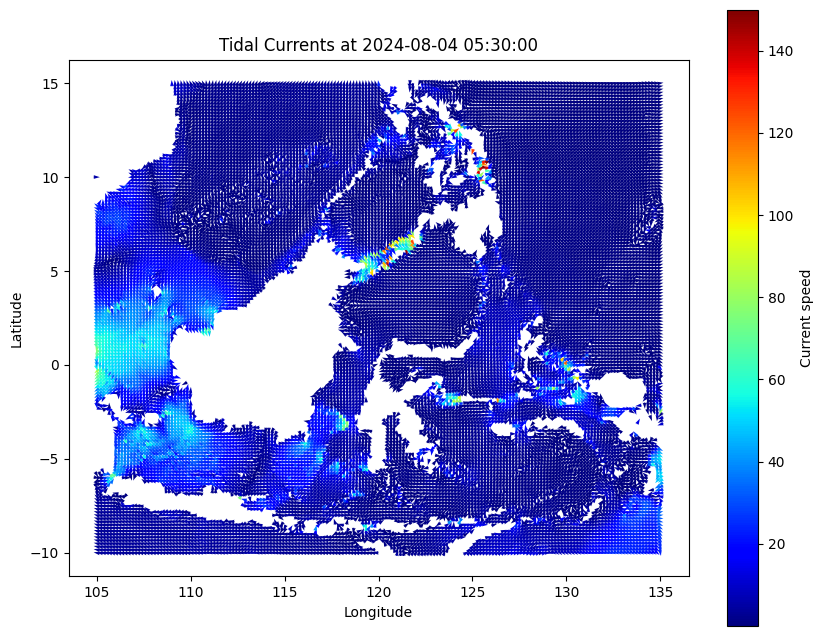

In [127]:
#10°S–15°N，105°–135°E
x5, y5, u5, v5, mag5 = current_quiver(adapter, 105, -10, 135, 15, tide_time, mask_grid=5)
plot_current_gradients(x5, y5, u5, v5, mag5, dtime[0], magmax=150)

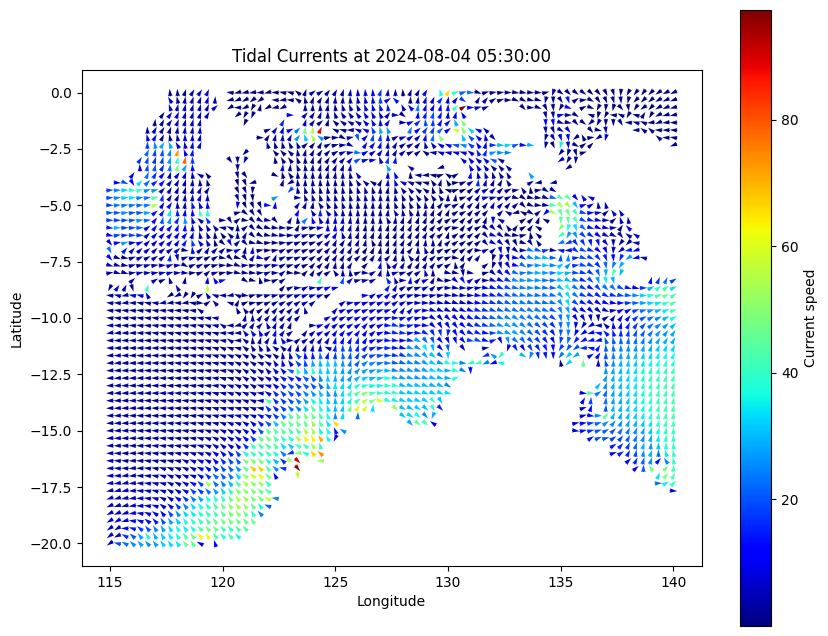

In [128]:
x5t, y5t, u5t, v5t, mag5t = current_quiver(adapter, 115, -20, 140, 0, tide_time, mask_grid=10)
plot_current_gradients(x5t, y5t, u5t, v5t, mag5t, dtime[0], magmax=150)

In [129]:
from timescale.time import convert_calendar_dates
#Test https://github.com/jerabaul29/pyTMD/blob/feat/full-example/example/pytmd_script_use_get_tide_elevation_current.ipynb
lat_to_predict = 72.502
lon_to_predict = 19.560
start_day_to_predict = datetime(2008, 9, 10, 0, 0, 0, tzinfo=timezone.utc)
number_of_hours_to_predict = 24*8
list_datetimes_to_predict = [start_day_to_predict + timedelta(hours=hr) for hr in range(number_of_hours_to_predict)]
pytmd_times_to_predict = [convert_calendar_dates(crrt_time.year, crrt_time.month, crrt_time.day, crrt_time.hour, crrt_time.minute, crrt_time.second) for crrt_time in list_datetimes_to_predict]
print(pytmd_times_to_predict)

[np.float64(6097.0), np.float64(6097.041666666511), np.float64(6097.083333333489), np.float64(6097.125), np.float64(6097.166666666511), np.float64(6097.208333333489), np.float64(6097.25), np.float64(6097.291666666511), np.float64(6097.333333333489), np.float64(6097.375), np.float64(6097.416666666511), np.float64(6097.458333333489), np.float64(6097.5), np.float64(6097.541666666511), np.float64(6097.583333333489), np.float64(6097.625), np.float64(6097.666666666511), np.float64(6097.708333333489), np.float64(6097.75), np.float64(6097.791666666511), np.float64(6097.833333333489), np.float64(6097.875), np.float64(6097.916666666511), np.float64(6097.958333333489), np.float64(6098.0), np.float64(6098.041666666511), np.float64(6098.083333333489), np.float64(6098.125), np.float64(6098.166666666511), np.float64(6098.208333333489), np.float64(6098.25), np.float64(6098.291666666511), np.float64(6098.333333333489), np.float64(6098.375), np.float64(6098.416666666511), np.float64(6098.458333333489), 

In [130]:
testsub, _ = plan_bbox(adapter, lon_to_predict, lon_to_predict, lat_to_predict, lat_to_predict, sample=1,
                       halo=0.5/30.0, max_cells=10_000_000)   # 繪圖用途,放寬 cap
testtide = get_tide_map(adapter, testsub, pytmd_times_to_predict,
                    type=['u', 'v'], drop_dim=False)
print(testtide)

{'u': masked_array(data=[[[0.9256646980366401, -1.5960976044706183,
                     -3.5460818549982362, -4.568683446144053,
                     -4.520859177682763, -3.482510090466076,
                     -1.7471293907479586, 0.2194655813430243,
                     1.8743951272312513, 2.7422980500405276,
                     2.5623467843274357, 1.3732055869877215,
                     -0.501882870166436, -2.5563704516474854,
                     -4.238424911780112, -5.078159963845526,
                     -4.783946154310229, -3.3082941038794993,
                     -0.8797126172129446, 2.0189443861934,
                     4.74492521503083, 6.65387585470622,
                     7.274966450119422, 6.4395786630832115,
                     4.32064315545664, 1.3808736539942474,
                     -1.740484641481195, -4.367882775384465,
                     -5.933705759536042, -6.109344387095801,
                     -4.89718627970589, -2.6485301118457825,
                     0

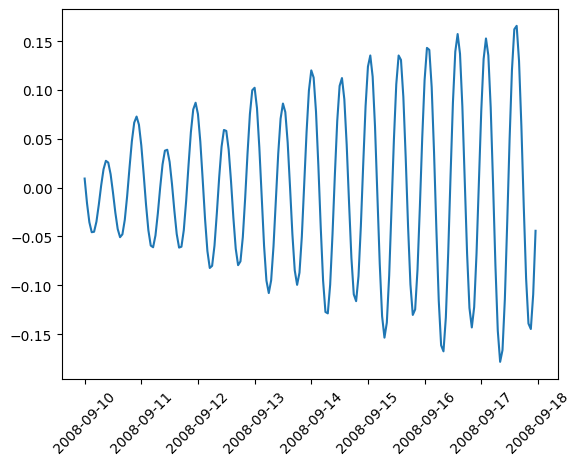

In [131]:
plt.figure()
plt.plot(list_datetimes_to_predict, testtide["u"].data[0,0,:]/100)
plt.xticks(rotation=45)
plt.show()

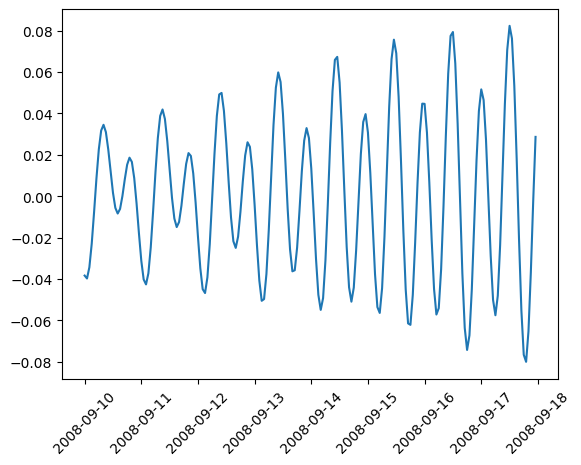

In [132]:
plt.figure()
plt.plot(list_datetimes_to_predict, testtide["v"].data[0,0,:]/100)
plt.xticks(rotation=45)
plt.show()